# Analysis of LT portfolios
- analyses the stochastic, the single deterministic optimal per grid expansion and the overall optimal without grid interruption

In [4]:
import os
os.environ["PROJ_DATA"] = "/home/julian-geis/repos/pypsa-de/.pixi/envs/default/share/proj"
os.environ.pop("PROJ_LIB", None)

import re
import sys
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa
import yaml
import pyproj
pyproj.datadir.set_data_dir("/home/julian-geis/repos/pypsa-de/.pixi/envs/default/share/proj")

sys.path.insert(0, "/home/julian-geis/repos/pypsa-de")
from scripts._helpers import rename_techs

plt.rcParams["figure.dpi"] = 110

## Config

Point at one `stochastic_grid_analysis` run. Everything else (clusters,
opts, sector_opts, planning horizon, which portfolios exist) is discovered
from the files actually present under it.

In [5]:
DIR = "/home/julian-geis/Documents/02_PhD/03RobustModelling/runs"
RUN_NAME = "202600717-stoch-grid-testing-2030-3H"
ARIADNE_SCENARIO = "KN2045_Mix"

RESULTS = Path(f"{DIR}/results/{RUN_NAME}/{ARIADNE_SCENARIO}/networks")
RESOURCES = Path(f"{DIR}/resources/{RUN_NAME}/{ARIADNE_SCENARIO}/networks")

STOCHASTIC_SCENARIOS = ["eev" , "reduced_10", "reduced_40", "stochastic"]

networks_optimal = {}
networks_robust = {}

for year in [2025, 2030]:
    networks_optimal[year] = pypsa.Network(RESULTS / f"base_s_27__none_{year}.nc")

for stoch_lt_scenarios in STOCHASTIC_SCENARIOS:
    networks_robust[stoch_lt_scenarios] = pypsa.Network(RESULTS / f"base_s_27__none_{year}_topology-{stoch_lt_scenarios}.nc")

            ('0', 1),
            ('0', 2),
            ('0', 3),
            ('0', 4),
            ('0', 5),
            ('0', 6),
            ('0', 7),
            ('1', 0),
            ('1', 1),
            ...
            ('8', 6),
            ('8', 7),
            ('9', 0),
            ('9', 1),
            ('9', 2),
            ('9', 3),
            ('9', 4),
            ('9', 5),
            ('9', 6),
            ('9', 7)],
           length=352) for attribute mu_neg of Line are not in main components dataframe lines
            ('0', 1),
            ('0', 2),
            ('0', 3),
            ('0', 4),
            ('0', 5),
            ('0', 6),
            ('0', 7),
            ('1', 0),
            ('1', 1),
            ...
            ('8', 6),
            ('8', 7),
            ('9', 0),
            ('9', 1),
            ('9', 2),
            ('9', 3),
            ('9', 4),
            ('9', 5),
            ('9', 6),
            ('9', 7)],
           length=352) for attribut

# German costs

In [6]:
from pypsa.statistics import get_transmission_carriers
# Add the scripts/pypsa-de directory to the path
scripts_path = os.path.join(os.path.dirname(os.getcwd()), "scripts", "pypsa-de")
sys.path.append(scripts_path)

from export_ariadne_variables import get_export_import

# calc system cost
def get_tsc(n, country, region="DE"):
    pypsa.options.set_option("params.statistics.drop_zero", False)
    capex = n.statistics.capex(
        groupby=pypsa.statistics.groupers["name", "carrier"], nice_names=False
    )

    opex = n.statistics.opex(
        groupby=pypsa.statistics.groupers["name", "carrier"], nice_names=False
    )

    # filter inter country transmission lines and links
    inter_country_lines = n.lines.bus0.map(n.buses.country) != n.lines.bus1.map(
        n.buses.country
    )
    inter_country_links = n.links.bus0.map(n.buses.country) != n.links.bus1.map(
        n.buses.country
    )
    #
    transmission_carriers = get_transmission_carriers(n).get_level_values("carrier")
    transmission_lines = (
        n.lines.carrier.isin(transmission_carriers) & n.lines.active
    )
    transmission_links = (
        n.links.carrier.isin(transmission_carriers) & n.links.active
    )
    #
    country_transmission_lines = (
        (n.lines.bus0.str.contains(country)) & ~(n.lines.bus1.str.contains(country))
    ) | (
        ~(n.lines.bus0.str.contains(country)) & (n.lines.bus1.str.contains(country))
    )
    country_tranmission_links = (
        (n.links.bus0.str.contains(country)) & ~(n.links.bus1.str.contains(country))
    ) | (
        ~(n.links.bus0.str.contains(country)) & (n.links.bus1.str.contains(country))
    )
    #
    inter_country_transmission_lines = (
        inter_country_lines & transmission_lines & country_transmission_lines
    )
    inter_country_transmission_links = (
        inter_country_links & transmission_links & country_tranmission_links
    )
    inter_country_transmission_lines_i = inter_country_transmission_lines[
        inter_country_transmission_lines
    ].index
    inter_country_transmission_links_i = inter_country_transmission_links[
        inter_country_transmission_links
    ].index
    inter_country_transmission_i = inter_country_transmission_lines_i.union(
        inter_country_transmission_links_i
    )

    #
    tsc = pd.concat([capex, opex], axis=1, keys=["capex", "opex"])
    tsc = tsc.reset_index().set_index("name")
    tsc.loc[inter_country_transmission_i, ["capex", "opex"]] = (
        tsc.loc[inter_country_transmission_i, ["capex", "opex"]] / 2
    )
    tsc.rename(
        index={
            index: index + " " + country for index in inter_country_transmission_i
        },
        inplace=True,
    )
    # rename inter region links and lines
    to_rename_links = n.links[
        (n.links.bus0.str.contains(region))
        & (n.links.bus1.str.contains(region))
        & ~(n.links.index.str.contains(region))
    ].index
    to_rename_lines = n.lines[
        (n.lines.bus0.str.contains(region))
        & (n.lines.bus1.str.contains(region))
        & ~(n.lines.index.str.contains(region))
    ].index
    tsc.rename(
        index={index: index + " " + region for index in to_rename_links},
        inplace=True,
    )
    tsc.rename(
        index={index: index + " " + region for index in to_rename_lines},
        inplace=True,
    )

    tsc = tsc.filter(like=country, axis=0)
    
    tsc_sum = (
        tsc.filter(like=country, axis=0)
        .drop("component", axis=1)
        .groupby("carrier")
        .sum()
    )

    return tsc_sum, tsc


def get_trade_cost(n, region, carriers):
    """
    Positive values mean cost for the domestic energy system (imports > exports)
    Negative values mean revenue for the domestic energy system (exports > imports)
    """
    export_revenue, import_cost = get_export_import(n, region, carriers, unit="€")
    return import_cost - export_revenue

In [7]:
def get_tsc(n, country, region="DE", exclude_grid_costs=None):
    """
    exclude_grid_costs:
        None (default) - auto-detect: if this network has any non-extendable Line/DC-Link
            (i.e. a stochastic_grid_scenarios topology-*/portfolio-* network, where grid
            capacity is exogenously fixed rather than a portfolio choice - same convention
            as scripts/pypsa-de/compute_stochastic_metrics.py's portfolio_capex()), those
            branches' capex/opex are dropped from the total and an info message is printed.
            A normal (fully grid-extendable) network is left untouched, byte-for-byte the
            original behaviour.
        True/False - force the behaviour explicitly, no auto-detection, no message.
    """
    pypsa.options.set_option("params.statistics.drop_zero", False)
    capex = n.statistics.capex(
        groupby=pypsa.statistics.groupers["name", "carrier"], nice_names=False
    )
    opex = n.statistics.opex(
        groupby=pypsa.statistics.groupers["name", "carrier"], nice_names=False
    )

    non_ext_lines = n.lines.index[~n.lines.s_nom_extendable]
    non_ext_links = n.links.index[(n.links.carrier == "DC") & ~n.links.p_nom_extendable]
    fixed_grid_i = non_ext_lines.union(non_ext_links)

    if exclude_grid_costs is None:
        exclude_grid_costs = len(fixed_grid_i) > 0
        if exclude_grid_costs:
            print(
                f"get_tsc: {len(fixed_grid_i)} non-extendable Line/DC-Link branch(es) found "
                "(exogenous grid_scenario topology) - excluding their capex/opex from the total."
            )

    # filter inter country transmission lines and links
    inter_country_lines = n.lines.bus0.map(n.buses.country) != n.lines.bus1.map(n.buses.country)
    inter_country_links = n.links.bus0.map(n.buses.country) != n.links.bus1.map(n.buses.country)

    transmission_carriers = get_transmission_carriers(n).get_level_values("carrier")
    transmission_lines = n.lines.carrier.isin(transmission_carriers) & n.lines.active
    transmission_links = n.links.carrier.isin(transmission_carriers) & n.links.active

    country_transmission_lines = (
        (n.lines.bus0.str.contains(country)) & ~(n.lines.bus1.str.contains(country))
    ) | (
        ~(n.lines.bus0.str.contains(country)) & (n.lines.bus1.str.contains(country))
    )
    country_tranmission_links = (
        (n.links.bus0.str.contains(country)) & ~(n.links.bus1.str.contains(country))
    ) | (
        ~(n.links.bus0.str.contains(country)) & (n.links.bus1.str.contains(country))
    )

    inter_country_transmission_lines = inter_country_lines & transmission_lines & country_transmission_lines
    inter_country_transmission_links = inter_country_links & transmission_links & country_tranmission_links
    inter_country_transmission_lines_i = inter_country_transmission_lines[inter_country_transmission_lines].index
    inter_country_transmission_links_i = inter_country_transmission_links[inter_country_transmission_links].index
    inter_country_transmission_i = inter_country_transmission_lines_i.union(inter_country_transmission_links_i)

    tsc = pd.concat([capex, opex], axis=1, keys=["capex", "opex"])
    tsc = tsc.reset_index().set_index("name")

    if exclude_grid_costs:
        tsc = tsc.drop(index=fixed_grid_i, errors="ignore")
        inter_country_transmission_i = inter_country_transmission_i.difference(fixed_grid_i)

    tsc.loc[inter_country_transmission_i, ["capex", "opex"]] = (
        tsc.loc[inter_country_transmission_i, ["capex", "opex"]] / 2
    )
    tsc.rename(
        index={index: index + " " + country for index in inter_country_transmission_i},
        inplace=True,
    )

    to_rename_links = n.links[
        (n.links.bus0.str.contains(region))
        & (n.links.bus1.str.contains(region))
        & ~(n.links.index.str.contains(region))
    ].index
    to_rename_lines = n.lines[
        (n.lines.bus0.str.contains(region))
        & (n.lines.bus1.str.contains(region))
        & ~(n.lines.index.str.contains(region))
    ].index
    tsc.rename(index={index: index + " " + region for index in to_rename_links}, inplace=True)
    tsc.rename(index={index: index + " " + region for index in to_rename_lines}, inplace=True)

    tsc = tsc.filter(like=country, axis=0)

    tsc_sum = (
        tsc.filter(like=country, axis=0)
        .drop("component", axis=1)
        .groupby("carrier")
        .sum()
    )

    return tsc_sum, tsc


In [8]:
capex = long_term_networks["2030-stochastic"].statistics.capex()

NameError: name 'long_term_networks' is not defined

In [ ]:
capex.unstack("scenario")

scenario                                 reduced_10    reduced_40
component carrier                                                
Generator Offshore Wind (AC)           1.935657e+10  1.935657e+10
          Offshore Wind (DC)           1.951710e+10  1.951710e+10
          Onshore Wind                 5.555915e+10  5.555915e+10
          Run of River                 1.064183e+10  1.064183e+10
          Solar                        8.812373e+09  8.812373e+09
...                                             ...           ...
Store     oil                          3.159491e+04  3.159491e+04
          rural water tanks            4.266678e+08  4.266678e+08
          uranium                      1.585056e+04  1.585056e+04
          urban central water tanks    1.070001e+09  1.070001e+09
          urban decentral water tanks  3.148737e+08  3.148737e+08

[124 rows x 2 columns]

In [ ]:
# carriers/components you've deliberately made scenario-dependent
scenario_dependent = [("Line", "AC"), ("Link", "DC")]

capex_wide = capex.unstack("scenario")

def resolve_capex(row):
    key = row.name  # (component, carrier)
    if key in scenario_dependent:
        return row  # keep per-scenario values, weight/sum with probabilities later
    else:
        return row.mean()  # collapse to single shared value (noise-averaged)

resolved = capex_wide.apply(resolve_capex, axis=1)

In [ ]:
resolved[(("Line", "AC"))]

scenario
reduced_10    7.549968e+09
reduced_40    6.397776e+09
Name: (Line, AC), dtype: float64

In [ ]:
resolved[(("Link", "DC"))]

scenario
reduced_10    1.173490e+10
reduced_40    1.083830e+10
Name: (Link, DC), dtype: float64

In [ ]:
long_term_networks.keys()

dict_keys(['2025', '2030', '2030-eev', '2030-reduced_10', '2030-reduced_40', '2030-stochastic'])

In [ ]:
opex = long_term_networks["2030-stochastic"].statistics.opex()

In [ ]:
opex = long_term_networks["2030-stochastic"].statistics.withdrawal

In [ ]:
opex.unstack("scenario")

scenario                                 reduced_10    reduced_40
component carrier                                                
Generator Offshore Wind (AC)           8.332183e+06  8.274876e+06
          Offshore Wind (DC)           7.686713e+06  7.545377e+06
          Onshore Wind                 2.657539e+07  2.633619e+07
          Run of River                 1.252776e+06  1.287977e+06
          Solar                        3.165055e+06  3.132345e+06
...                                             ...           ...
Store     oil                         -0.000000e+00 -0.000000e+00
          rural water tanks           -9.740241e+03 -9.926601e+03
          uranium                      0.000000e+00 -0.000000e+00
          urban central water tanks   -1.386588e+04 -1.358365e+04
          urban decentral water tanks -7.752258e+03 -7.471179e+03

[123 rows x 2 columns]

In [ ]:
for network, name in zip(long_term_networks.values(), long_term_networks.keys()):
    tsc_sum, tsc = get_tsc(network, "DE", exclude_grid_costs=True)
    print(f"Total Energy System Cost for {name}: {tsc_sum.sum().sum() / 1e9:.2f} billion €")

Total Energy System Cost for Unnamed Network: 152.89 billion €
Total Energy System Cost for Unnamed Network: 150.21 billion €
Total Energy System Cost for Unnamed Network: 145.51 billion €
Total Energy System Cost for Unnamed Network: 145.48 billion €
Total Energy System Cost for Unnamed Network: 145.73 billion €


KeyError: "None of [Index([                                               ('reduced_10', 'DC2'),\n                                             ('reduced_10', 'DC2-reversed'),\n                               ('reduced_10', 'DE methanol -> EU methanol'),\n                               ('reduced_10', 'EU methanol -> DE methanol'),\n                          ('reduced_10', 'H2 pipeline AT2 0 -> DE2 0-2030'),\n                 ('reduced_10', 'H2 pipeline AT2 0 -> DE2 0-reversed-2030'),\n                          ('reduced_10', 'H2 pipeline AT2 0 -> DE2 4-2030'),\n                 ('reduced_10', 'H2 pipeline AT2 0 -> DE2 4-reversed-2030'),\n                ('reduced_10', 'H2 pipeline BE2 0 <-> DE2 1-kernnetz-2030'),\n       ('reduced_10', 'H2 pipeline BE2 0 <-> DE2 1-kernnetz-2030-reversed'),\n       ...\n                                             ('reduced_40', 'TYNDP2020_38'),\n                                    ('reduced_40', 'TYNDP2020_38-reversed'),\n                                

## Electricity capacity comparison

1:1 reproduction of the `optimal_capacity(bus_carrier=["AC","low voltage"])`
horizontal-bar comparison, `REGION`-filtered, with values labeled directly
on the bars (and the full numeric table below). Sign follows PyPSA
statistics' own convention for this `groupby=["bus","carrier"]` view:
**positive = supply-side** capacity at that bus carrier, **negative =
demand/withdrawal-side** capacity (chargers, resistive heaters, BEV
charging, grid losses) - not a bug, this is what tells renewables/backup
apart from demand-side conversion capacity below.

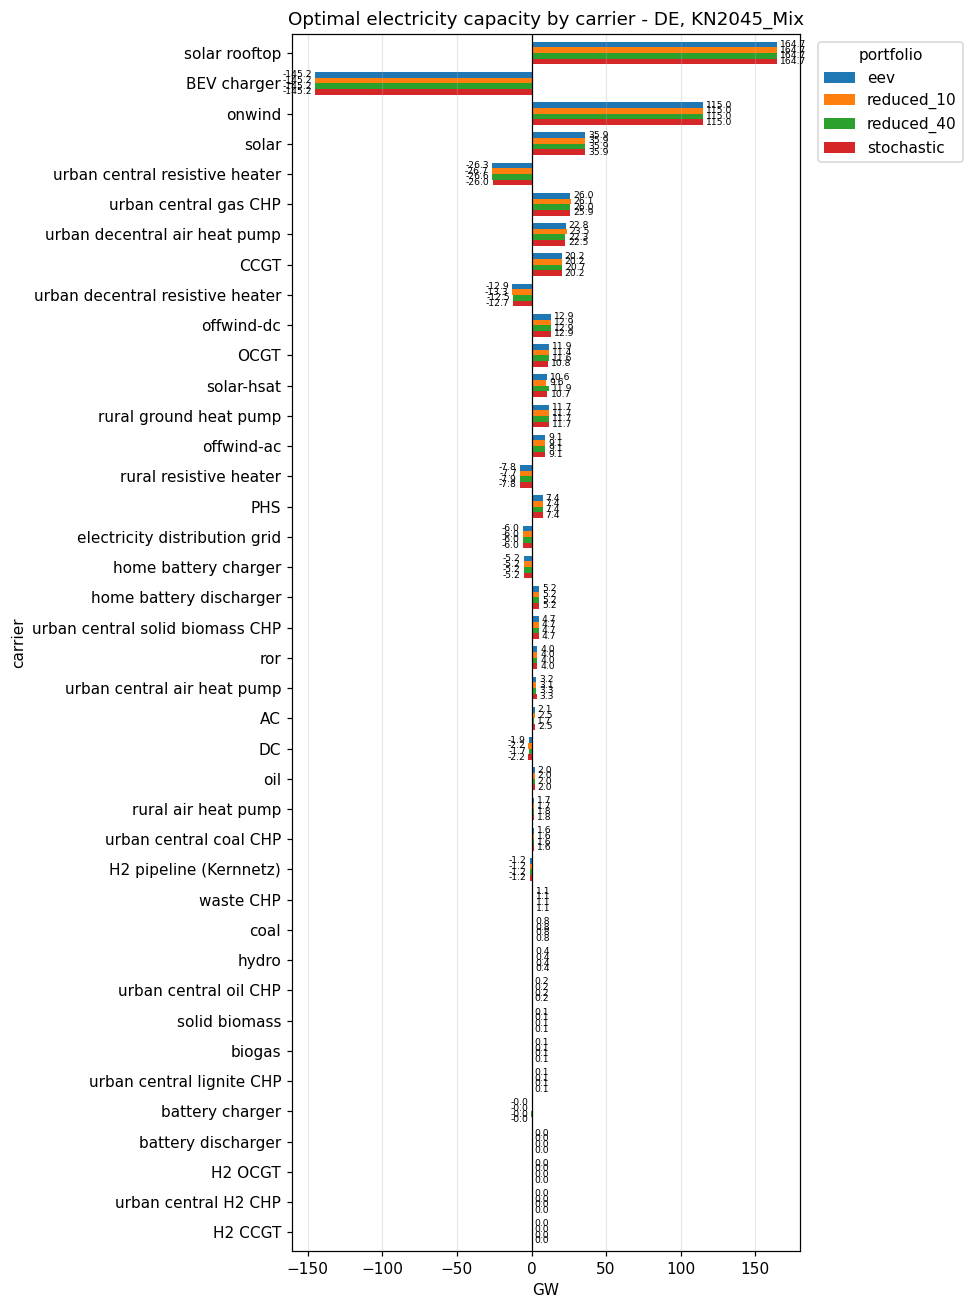

,eev,reduced_10,reduced_40,stochastic
carrier,,,,
solar rooftop,164.69,164.69,164.69,164.69
BEV charger,-145.16,-145.16,-145.16,-145.16
onwind,115.00,115.00,115.00,115.00
solar,35.93,35.93,35.93,35.93
urban central resistive heater,-26.32,-26.75,-26.58,-26.01
urban central gas CHP,25.97,26.13,25.95,25.94
urban decentral air heat pump,22.81,23.49,22.32,22.46
CCGT,20.23,20.23,20.74,20.24
urban decentral resistive heater,-12.87,-13.28,-12.50,-12.67


In [ ]:
elec_kwargs = dict(groupby=pypsa.statistics.groupers["bus", "carrier"], nice_names=False)

elec_cap = {}
for portfolio, n in topology_networks.items():
    cap = n.statistics.optimal_capacity(bus_carrier=["AC", "low voltage"], **elec_kwargs)
    elec_cap[portfolio] = region_filter(cap).groupby("carrier").sum().div(1e3)
elec_cap = pd.DataFrame(elec_cap).reindex(columns=PORTFOLIOS).fillna(0)
elec_cap = elec_cap.loc[elec_cap.abs().max(axis=1) > 1e-3]
elec_cap = elec_cap.loc[elec_cap.abs().max(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(9, 12))
elec_cap.plot(kind="barh", ax=ax, color=[PORTFOLIO_COLORS[p] for p in elec_cap.columns], width=0.75)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=6, padding=2)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("GW")
ax.set_title(f"Optimal electricity capacity by carrier - {REGION}, {SCENARIO}")
ax.legend(title="portfolio", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(elec_cap.round(2))

### By function: renewables / backup / storage / demand-side

Same numbers, grouped into four functional buckets so the picture isn't
lost in ~40 individual carriers. Carriers not explicitly listed fall back
to "backup" if net supply-side, "demand-side" if net withdrawal-side
(printed below so the fallback stays visible rather than silently
mis-bucketing something).

fell back to sign-based bucketing: ['urban central gas CHP', 'CCGT', 'OCGT', 'urban central solid biomass CHP', 'oil', 'urban central coal CHP', 'waste CHP', 'coal', 'urban central oil CHP', 'solid biomass', 'biogas', 'urban central lignite CHP', 'H2 OCGT', 'urban central H2 CHP', 'H2 CCGT']


,eev,reduced_10,reduced_40,stochastic
renewables,352.2,351.3,353.5,352.3
backup,68.9,68.5,69.1,67.7
storage,13.0,13.0,13.0,13.0
demand-side,248.1,249.9,247.0,248.0


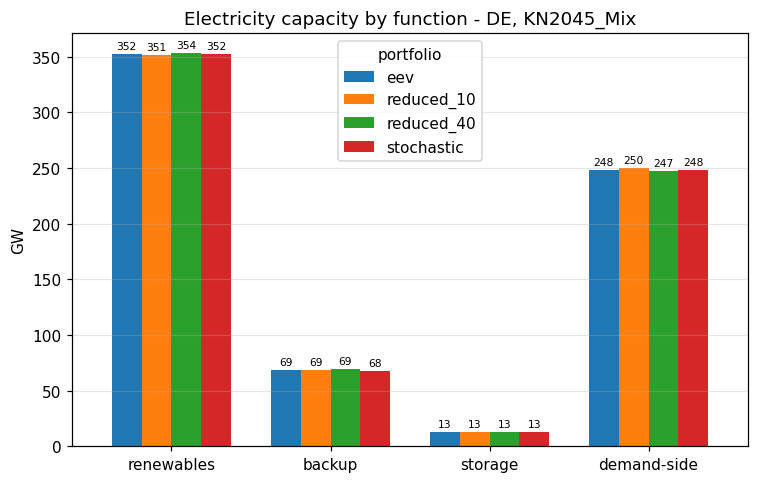


peak electrical load [GW] (DE):


eev           72.1
reduced_10    72.1
reduced_40    72.1
stochastic    72.1
Name: GW, dtype: float64

In [ ]:
RENEWABLE_CARRIERS = {"onwind", "offwind-ac", "offwind-dc", "offwind-float", "solar", "solar rooftop", "solar-hsat", "ror"}
STORAGE_CARRIERS = {"PHS", "hydro", "battery discharger", "home battery discharger", "iron-air battery discharger", "H2 Fuel Cell"}
DEMAND_CARRIERS = {
    "BEV charger", "battery charger", "home battery charger", "iron-air battery charger",
    "rural resistive heater", "urban decentral resistive heater", "urban central resistive heater",
    "rural air heat pump", "rural ground heat pump",
    "urban decentral air heat pump", "urban central air heat pump",
    "electricity distribution grid", "DC", "AC",
    "H2 Electrolysis", "H2 pipeline", "H2 pipeline (Kernnetz)", "DAC", "methanolisation",
}
BUCKET_ORDER = ["renewables", "backup", "storage", "demand-side"]

carrier_sign = np.sign(elec_cap.sum(axis=1))


def bucket_of(carrier):
    if carrier in RENEWABLE_CARRIERS:
        return "renewables"
    if carrier in STORAGE_CARRIERS:
        return "storage"
    if carrier in DEMAND_CARRIERS:
        return "demand-side"
    return "backup" if carrier_sign[carrier] >= 0 else "demand-side"


buckets = pd.Series({c: bucket_of(c) for c in elec_cap.index})
fallback = [c for c in elec_cap.index
            if c not in RENEWABLE_CARRIERS | STORAGE_CARRIERS | DEMAND_CARRIERS]
print(f"fell back to sign-based bucketing: {fallback}")

bucketed = elec_cap.abs().groupby(buckets).sum().reindex(BUCKET_ORDER).fillna(0)
display(bucketed.round(1))

fig, ax = plt.subplots(figsize=(7, 4.5))
bucketed.plot.bar(ax=ax, width=0.75, color=[PORTFOLIO_COLORS[p] for p in bucketed.columns])
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=7, padding=2)
ax.set_ylabel("GW")
ax.set_title(f"Electricity capacity by function - {REGION}, {SCENARIO}")
ax.legend(title="portfolio")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# peak electrical load, for scale against renewables+backup+storage above (not itself a
# "capacity" bucket, so kept as a reference number rather than a fifth bar). Loads' own
# `carrier` is the end-use type ("industry electricity", ...), not the bus carrier - filter
# via the bus's carrier instead. get_switchable_as_dense (not loads_t.p_set directly) because
# constant-profile loads live in the static p_set column, not the time-varying one.
peak_load_gw = {}
for portfolio, n in topology_networks.items():
    de_elec_loads = n.loads[n.buses.loc[n.loads.bus, "carrier"].isin(["AC", "low voltage"]).to_numpy()]
    if REGION != "whole_network":
        de_elec_loads = de_elec_loads.loc[n.buses.loc[de_elec_loads.bus, "country"].to_numpy() == REGION]
    loads_dense = n.get_switchable_as_dense("Load", "p_set")
    peak_load_gw[portfolio] = loads_dense[de_elec_loads.index].sum(axis=1).max() / 1e3
print(f"\npeak electrical load [GW] ({REGION}):")
display(pd.Series(peak_load_gw, name="GW").reindex(PORTFOLIOS).round(1))

## Grid topology comparison

Per-branch effective capacity (opt if solved, else nom) for AC lines and DC
links, loaded straight from each portfolio's own `topology-*.nc` network -
unlike the lumped totals above, this shows *where* the portfolios' backbones
actually differ.

,eev,reduced_10,reduced_40,stochastic
"Line (AC), GW",306.1,348.5,261.8,336.5
"Link (DC), GW",146.9,153.9,140.3,157.4


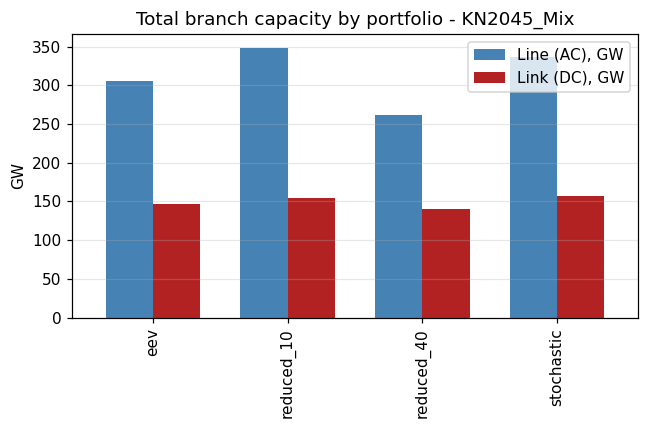

In [ ]:
NOM_ATTR = {"Line": "s_nom", "Link": "p_nom"}


def branch_frame(n, component):
    nom = NOM_ATTR[component]
    df = n.lines if component == "Line" else n.links.query("carrier == 'DC'")
    opt = df[f"{nom}_opt"]
    capacity = opt if (opt > 0).any() else df[nom]
    return pd.DataFrame({"capacity_mw": capacity, "bus0": df.bus0, "bus1": df.bus1})


total_branch_capacity = pd.DataFrame(
    {
        portfolio: {
            "Line (AC), GW": branch_frame(n, "Line").capacity_mw.sum() / 1e3,
            "Link (DC), GW": branch_frame(n, "Link").capacity_mw.sum() / 1e3,
        }
        for portfolio, n in topology_networks.items()
    }
).reindex(columns=PORTFOLIOS)

display(total_branch_capacity.round(1))

fig, ax = plt.subplots(figsize=(6, 4))
total_branch_capacity.T.plot.bar(ax=ax, color=["steelblue", "firebrick"], width=0.7)
ax.set_ylabel("GW")
ax.set_title(f"Total branch capacity by portfolio - {SCENARIO}")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Where does `stochastic` build differently than `eev`?

The naive planner (`eev`) and the hedged planner (`stochastic`) see the
same expected-cost picture but choose different first-stage grids. Largest
per-branch capacity deltas between the two, and a map of the same.

In [ ]:
if "eev" in topology_networks and "stochastic" in topology_networks:
    for component in ["Line", "Link"]:
        a = branch_frame(topology_networks["eev"], component)
        b = branch_frame(topology_networks["stochastic"], component)
        idx = a.index.union(b.index)
        delta = b.capacity_mw.reindex(idx).fillna(0) - a.capacity_mw.reindex(idx).fillna(0)
        top = delta.abs().sort_values(ascending=False).head(8)
        print(f"\n{component}: stochastic - eev capacity delta [MW], top {len(top)}")
        display(delta.loc[top.index].round(1).rename("delta_mw"))


Line: stochastic - eev capacity delta [MW], top 8


name
19    3278.0
10    2989.5
31    2842.5
27    2406.0
11   -2229.3
34    2225.0
22    2111.5
25    1716.0
Name: delta_mw, dtype: float64


Link: stochastic - eev capacity delta [MW], top 8


name
TYNDP2024_1229-reversed    600.0
TYNDP2024_1229             600.0
DC5-reversed               300.0
DC20-reversed              300.0
DC40-reversed              300.0
DC40plus-reversed          300.0
DC1-reversed               300.0
DC42plus-reversed          300.0
Name: delta_mw, dtype: float64

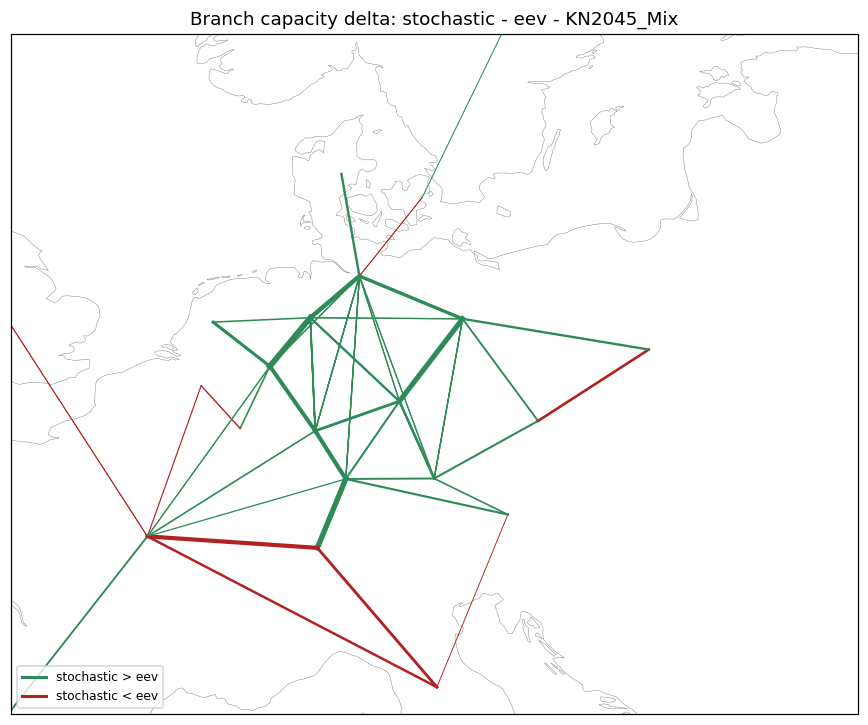

In [ ]:
if "eev" in topology_networks and "stochastic" in topology_networks:
    n_ref = topology_networks["eev"]
    proj = ccrs.EqualEarth()
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": proj})
    ax.coastlines(resolution="50m", linewidth=0.3, color="gray")
    ax.set_extent([-1, 24, 43, 60], crs=ccrs.PlateCarree())

    for component in ["Line", "Link"]:
        a = branch_frame(topology_networks["eev"], component)
        b = branch_frame(topology_networks["stochastic"], component)
        idx = a.index.intersection(b.index)
        delta = b.capacity_mw.loc[idx] - a.capacity_mw.loc[idx]
        for name, d in delta.items():
            if abs(d) < 50:
                continue
            row = a.loc[name]
            x = [n_ref.buses.at[row.bus0, "x"], n_ref.buses.at[row.bus1, "x"]]
            y = [n_ref.buses.at[row.bus0, "y"], n_ref.buses.at[row.bus1, "y"]]
            color = "seagreen" if d > 0 else "firebrick"
            ax.plot(x, y, transform=ccrs.PlateCarree(), color=color, lw=0.5 + abs(d) / 1000, zorder=2)

    handles = [plt.Line2D([0], [0], color=c, lw=2, label=l)
               for c, l in [("seagreen", "stochastic > eev"), ("firebrick", "stochastic < eev")]]
    ax.legend(handles=handles, loc="lower left", fontsize=8)
    ax.set_title(f"Branch capacity delta: stochastic - eev - {SCENARIO}")
    plt.tight_layout()
    plt.show()

## Spatial capacity comparison per carrier

`CARRIER_TO_MAP` picks any `Generator`/`StorageUnit` carrier (default
`"onwind"`). For this run, DE-wide onshore wind capacity is *exactly*
identical across all four portfolios (115.0 GW - some national potential
constraint binding everywhere), so the interesting question is purely
**where inside Germany** it gets sited, which the panel map and delta maps
below make visible bus by bus.

`optimal` is the unconstrained reference network (grid Lines/DC-Links left
freely extendable rather than fixed to a portfolio's topology - "what if the
grid could expand to its own optimum, no delay"). It isn't part of
`PORTFOLIOS` and stays out of every cost/capacity-bucket comparison above
(grid buildout cost is endogenous there, exogenous everywhere else - not
capex-comparable), but is a natural reference point for siting: is a
portfolio's wind layout closer to or further from what the grid would
choose with no topology constraint at all?

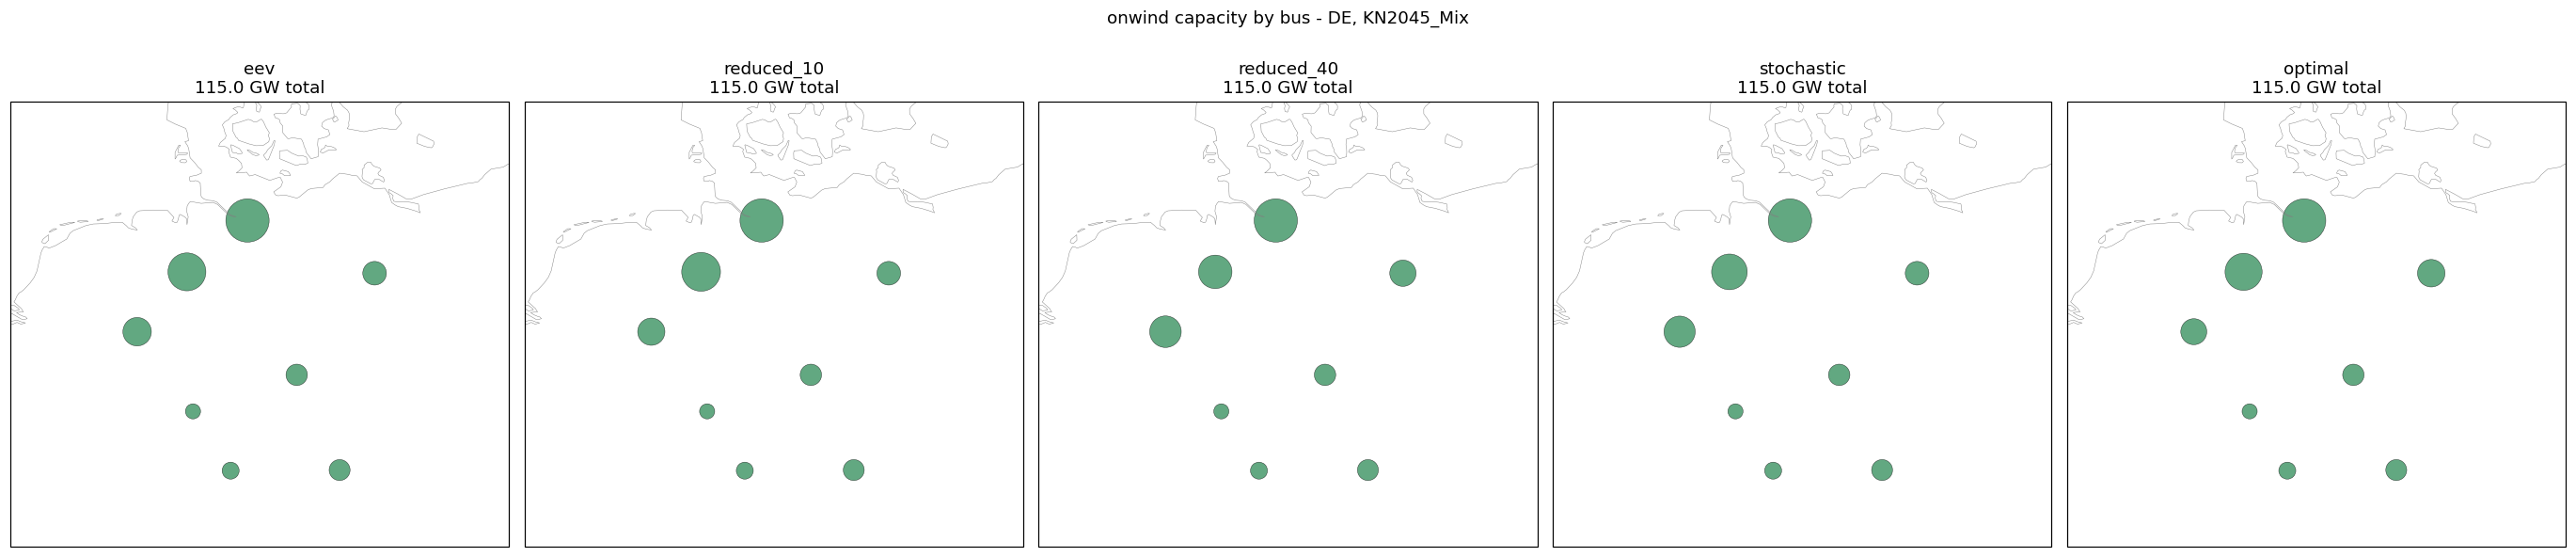

In [ ]:
CARRIER_TO_MAP = "onwind"  # "onwind" | "offwind-ac" | "offwind-dc" | "solar" | "battery discharger" | "BEV charger"


def bus_capacity_for_carrier(n, carrier, region=None):
    region = REGION if region is None else region
    gens = n.generators.query("carrier == @carrier")
    su = n.storage_units.query("carrier == @carrier")
    caps = pd.concat([gens.p_nom_opt, su.p_nom_opt])
    bus = pd.concat([gens.bus, su.bus])
    df = pd.DataFrame({"bus": bus.values, "capacity_mw": caps.values})
    if region != "whole_network":
        df = df.loc[n.buses.loc[df.bus, "country"].to_numpy() == region]
    return df.groupby("bus").capacity_mw.sum()


map_networks = dict(topology_networks)
if optimal_network is not None:
    map_networks["optimal"] = optimal_network

per_map_bus_cap = {p: bus_capacity_for_carrier(n, CARRIER_TO_MAP) for p, n in map_networks.items()}
vmax = max((s.max() for s in per_map_bus_cap.values() if len(s)), default=1.0)
map_extent = [4, 16, 47, 56] if REGION == "DE" else [-11, 30, 34, 65]

proj = ccrs.EqualEarth()
fig, axes = plt.subplots(1, len(map_networks), figsize=(5 * len(map_networks), 6), subplot_kw={"projection": proj})
for ax, portfolio in zip(axes, map_networks):
    s = per_map_bus_cap[portfolio]
    ax.coastlines(resolution="50m", linewidth=0.3, color="gray")
    ax.set_extent(map_extent, crs=ccrs.PlateCarree())
    bx = REFERENCE_NETWORK.buses.loc[s.index]
    ax.scatter(bx.x, bx.y, s=(s.values / vmax) * 900 + 8, transform=ccrs.PlateCarree(),
               color="seagreen", alpha=0.75, edgecolor="black", linewidth=0.3)
    ax.set_title(f"{portfolio}\n{s.sum() / 1e3:.1f} GW total")
fig.suptitle(f"{CARRIER_TO_MAP} capacity by bus - {REGION}, {SCENARIO}")
plt.tight_layout()
plt.show()

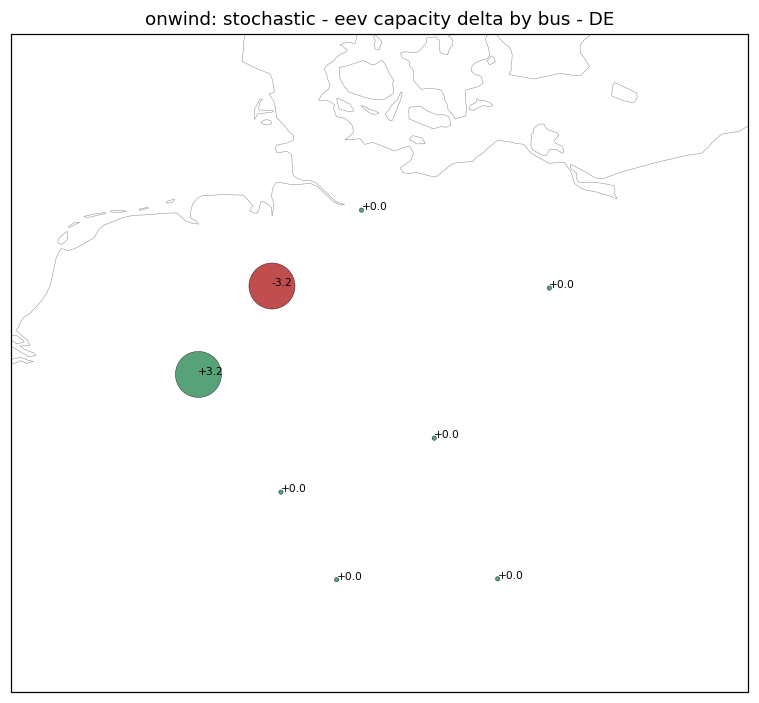

Delta onwind capacity, stochastic - eev [GW]:
  north (lat > 50.8): -0.00
  south (lat <= 50.8): +0.00



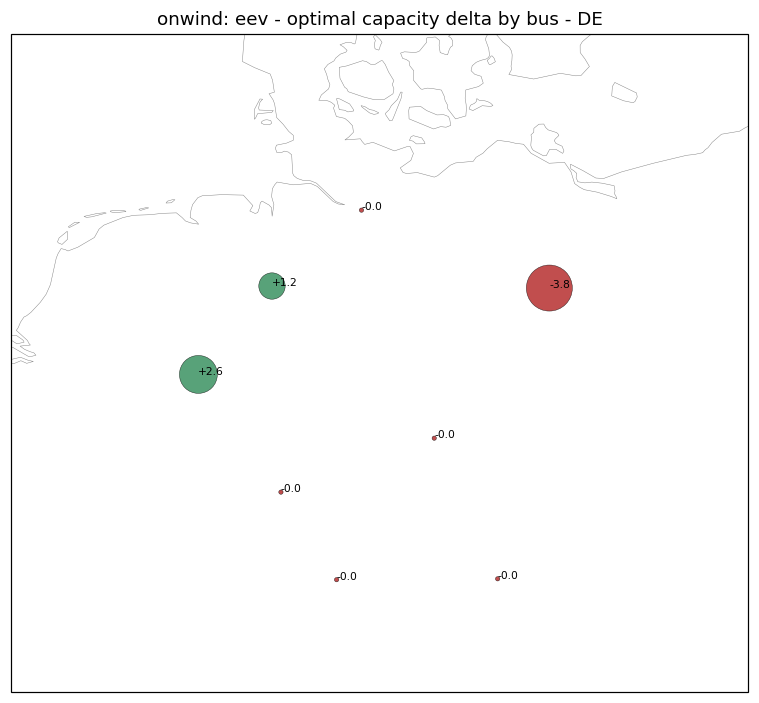

Delta onwind capacity, eev - optimal [GW]:
  north (lat > 50.8): +0.00
  south (lat <= 50.8): -0.00



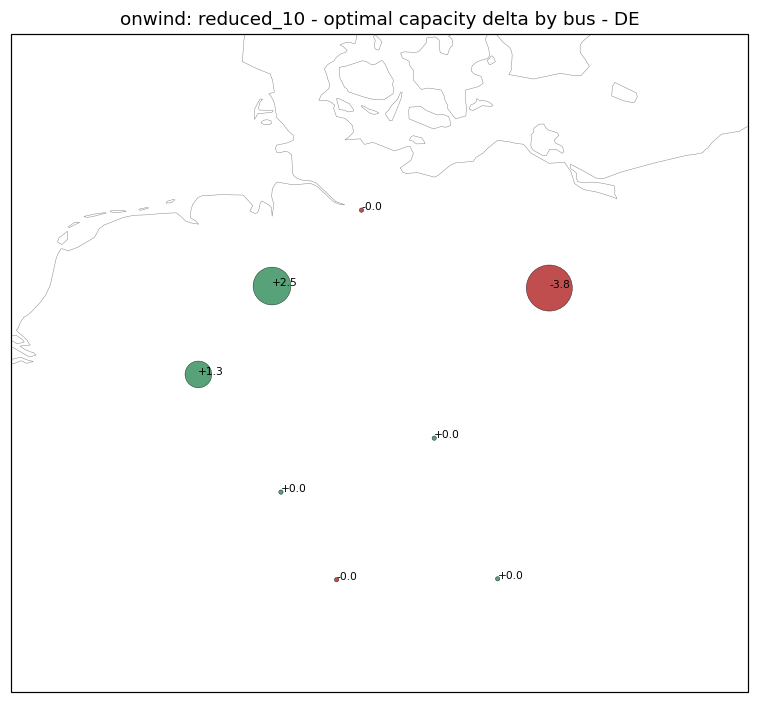

Delta onwind capacity, reduced_10 - optimal [GW]:
  north (lat > 50.8): -0.00
  south (lat <= 50.8): +0.00



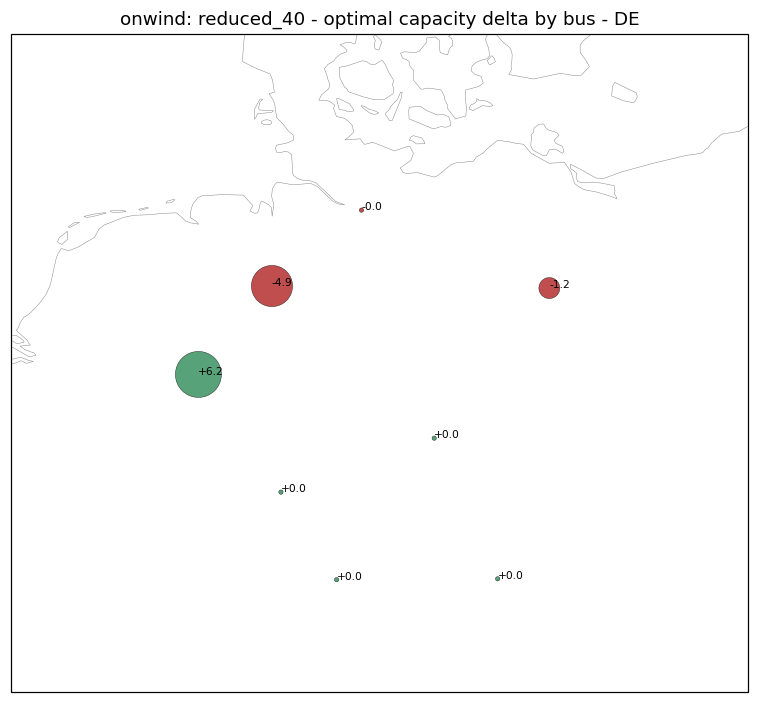

Delta onwind capacity, reduced_40 - optimal [GW]:
  north (lat > 50.8): -0.00
  south (lat <= 50.8): +0.00



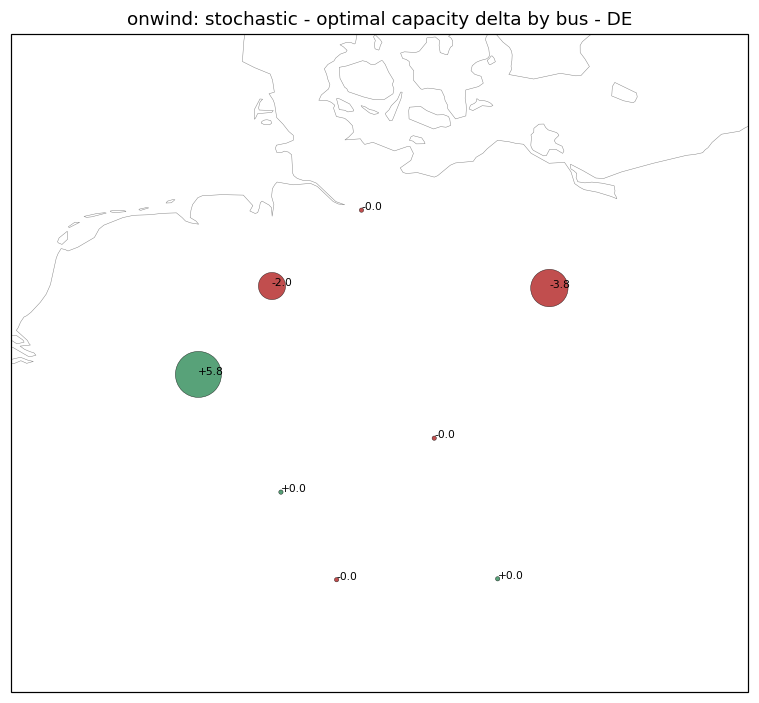

Delta onwind capacity, stochastic - optimal [GW]:
  north (lat > 50.8): +0.00
  south (lat <= 50.8): -0.00


In [ ]:
de_buses = REFERENCE_NETWORK.buses.query("country == 'DE' and carrier == 'AC'")
lat_mid = de_buses.y.median()
north, south = de_buses[de_buses.y > lat_mid].index, de_buses[de_buses.y <= lat_mid].index


def plot_and_split_delta(name_a, name_b, title):
    a, b = per_map_bus_cap[name_a], per_map_bus_cap[name_b]
    idx = a.index.union(b.index)
    delta = b.reindex(idx).fillna(0) - a.reindex(idx).fillna(0)

    fig, ax = plt.subplots(figsize=(7, 8), subplot_kw={"projection": proj})
    ax.coastlines(resolution="50m", linewidth=0.3, color="gray")
    ax.set_extent(map_extent, crs=ccrs.PlateCarree())
    bx = REFERENCE_NETWORK.buses.loc[idx]
    dmax = delta.abs().max() or 1.0
    colors = ["seagreen" if d > 0 else "firebrick" for d in delta]
    ax.scatter(bx.x, bx.y, s=(delta.abs().values / dmax) * 900 + 8, color=colors,
               transform=ccrs.PlateCarree(), alpha=0.8, edgecolor="black", linewidth=0.3)
    for bus, d in delta.items():
        if abs(d) < 1e-6:
            continue
        ax.text(bx.at[bus, "x"], bx.at[bus, "y"], f"{d / 1e3:+.1f}", transform=ccrs.PlateCarree(), fontsize=7)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    delta_gw = delta.reindex(de_buses.index).fillna(0) / 1e3
    print(f"Delta {CARRIER_TO_MAP} capacity, {name_b} - {name_a} [GW]:")
    print(f"  north (lat > {lat_mid:.1f}): {delta_gw.reindex(north).sum():+.2f}")
    print(f"  south (lat <= {lat_mid:.1f}): {delta_gw.reindex(south).sum():+.2f}")


if "eev" in per_map_bus_cap and "stochastic" in per_map_bus_cap:
    plot_and_split_delta("eev", "stochastic", f"{CARRIER_TO_MAP}: stochastic - eev capacity delta by bus - {REGION}")

if "optimal" in per_map_bus_cap:
    for portfolio in PORTFOLIOS:
        print()
        plot_and_split_delta("optimal", portfolio, f"{CARRIER_TO_MAP}: {portfolio} - optimal capacity delta by bus - {REGION}")

## Sector capacity by carrier (electricity / heat / H2)

Optimal capacity per bus-carrier group, `REGION`-filtered, stacked by
carrier (this run's own `tech_colors`) with one stacked bar per portfolio -
here the units are consistent within each group (all MW), so stacking is
meaningful, unlike the mixed-sign view above.

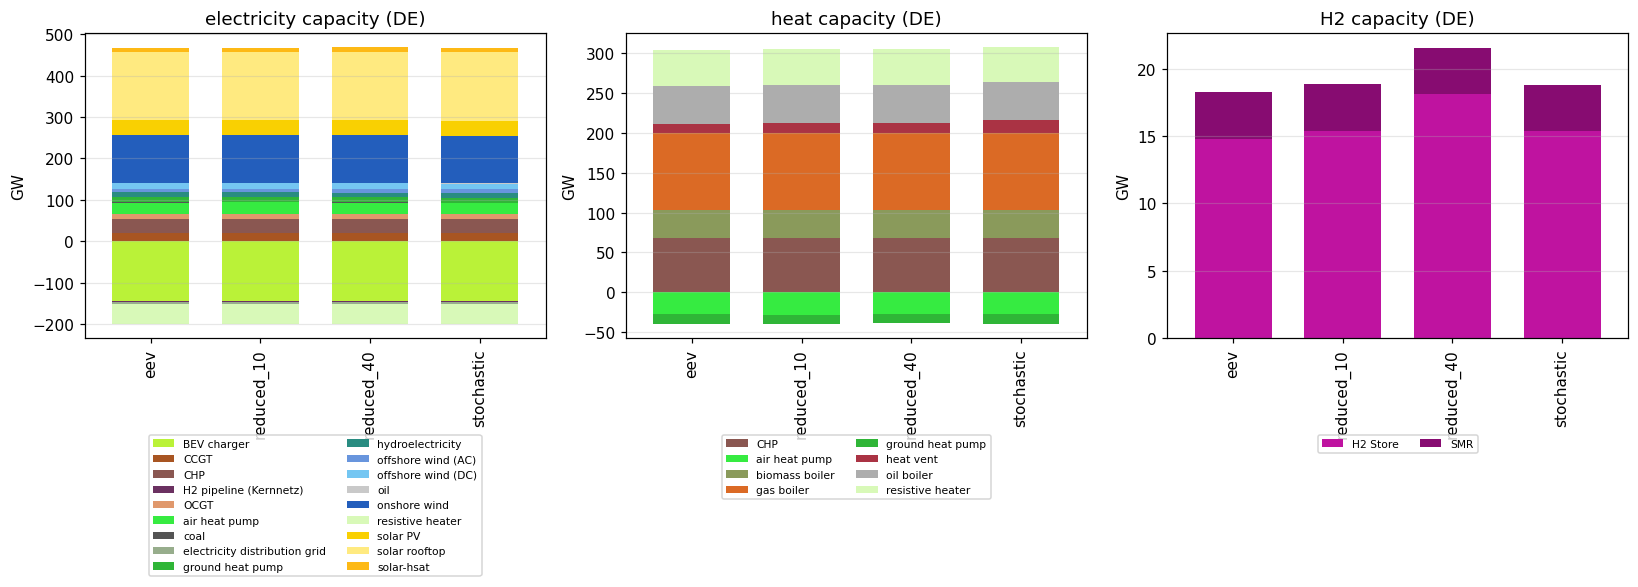

In [ ]:
BUS_CARRIER_GROUPS = {
    "electricity": ["AC", "low voltage"],
    "heat": ["urban central heat", "urban decentral heat", "rural heat"],
    "H2": ["H2"],
}

stats_kwargs = dict(groupby=pypsa.statistics.groupers["bus", "carrier"], nice_names=False)

fig, axes = plt.subplots(1, len(BUS_CARRIER_GROUPS), figsize=(15, 6))
for ax, (group_name, bus_carriers) in zip(axes, BUS_CARRIER_GROUPS.items()):
    per_portfolio = {}
    for portfolio in PORTFOLIOS:
        n = topology_networks[portfolio]
        cap = n.statistics.optimal_capacity(bus_carrier=bus_carriers, **stats_kwargs)
        per_portfolio[portfolio] = region_filter(cap).groupby("carrier").sum().div(1e3)
    df = pd.DataFrame(per_portfolio).fillna(0)
    df = df.groupby(df.index.map(rename_techs)).sum()
    df = df.loc[df.abs().max(axis=1) > 0.5]  # drop negligible carriers
    colors = [tech_colors.get(c, "#808080") for c in df.index]
    df.T.plot.bar(ax=ax, stacked=True, color=colors, legend=False, width=0.7)
    ax.set_title(f"{group_name} capacity ({REGION})")
    ax.set_ylabel("GW")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## Takeaways / next steps

- The metrics bar chart + cost-matrix heatmap are CSV-only (no network
  loading) - the cheapest candidate to wire into `stochastic_grid.smk` next,
  e.g. a `plot_stochastic_grid_metrics` rule right after
  `compute_stochastic_metrics`.
- The grid-topology, capacity, and spatial sections all need the actual
  `topology-*.nc` networks (heavier), so would be a separate,
  optionally-enabled plotting rule.